# `01` Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier




----------------------------

# `02` Load Data


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [29]:
test.shape

(13840, 17)

In [3]:
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


# Spliting and shuffle the data 

In [4]:
X_tr = train.drop("NObeyesdad",axis=1)
y_tr = train['NObeyesdad']

In [5]:
X_train,X_val,y_train,y_val = train_test_split(X_tr,y_tr,test_size=0.2,random_state=1234)

----------------

# `03` Exploratory Data Analysis (EDA)

## `i` Simple Analysis

Preview data, perform statistical data analysis and explore as much as needed to better understand the data set we're dealing with.




In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16606 entries, 13224 to 1318
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              16606 non-null  int64  
 1   Gender                          16606 non-null  object 
 2   Age                             16606 non-null  float64
 3   Height                          16606 non-null  float64
 4   Weight                          16606 non-null  float64
 5   family_history_with_overweight  16606 non-null  object 
 6   FAVC                            16606 non-null  object 
 7   FCVC                            16606 non-null  float64
 8   NCP                             16606 non-null  float64
 9   CAEC                            16606 non-null  object 
 10  SMOKE                           16606 non-null  object 
 11  CH2O                            16606 non-null  float64
 12  SCC                             16

In [7]:
X_train.isnull().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
dtype: int64

1- There is no null 

2- object column --> Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS

3- there is some strange data types like:


   -age ---> float values 
   
   -NCP(number of main meals) ---> float values
   

In [8]:
X_train.describe()

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,16606.000000,16606.000000,16606.000000,16606.000000,16606.000000,16606.000000,16606.000000,16606.000000,16606.000000
mean,10370.810851,23.832338,1.699865,87.837572,2.444577,2.757329,2.029247,0.978076,0.617031
std,5989.458205,5.694889,0.087415,26.419232,0.534559,0.709609,0.606690,0.833713,0.601551
min,0.000000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5195.250000,20.000000,1.631547,66.000000,2.000000,3.000000,1.796260,0.007050,0.000000
50%,10381.000000,22.771612,1.700000,84.000000,2.392179,3.000000,2.000000,1.000000,0.572185
75%,15541.750000,26.000000,1.761773,111.600553,3.000000,3.000000,2.535629,1.582675,1.000000
max,20757.000000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


need to look more deep in FAF,NCP their qurtalies seems not normal.

#### Checking Consistency of the coulmns : 

In [31]:
unique_NCP= X_train['NCP'].value_counts()
unique_NCP

NCP
3.0    13004
1.0     2031
4.0      838
2.0      733
Name: count, dtype: int64

I Think the true values are 1,2,3,4 so we need to make a function to turn the float values to the integer values (1,2,3,4).

In [10]:
unique_FAF= X_train['FAF'].value_counts()
unique_FAF

FAF
0.000000    4047
1.000000    3334
2.000000    1918
3.000000     620
1.097905      47
            ... 
0.268983       1
0.669278       1
0.105408       1
1.127425       1
1.884520       1
Name: count, Length: 1291, dtype: int64

I think the true values are 0,1,2,3 and the other float values need to be 0,1,2,3

In [ ]:
label = y_train.value_counts()
label

NObeyesdad
Obesity_Type_III       3216
Obesity_Type_II        2599
Normal_Weight          2503
Obesity_Type_I         2322
Overweight_Level_II    2017
Insufficient_Weight    2013
Overweight_Level_I     1936
Name: count, dtype: int64

there may be some bias so we will try first


## `ii` Visual Analysis

Plot graphs and relations in order to gain more insights about the data set, identify patterns, and make assumptions.


#### Univariate visualization

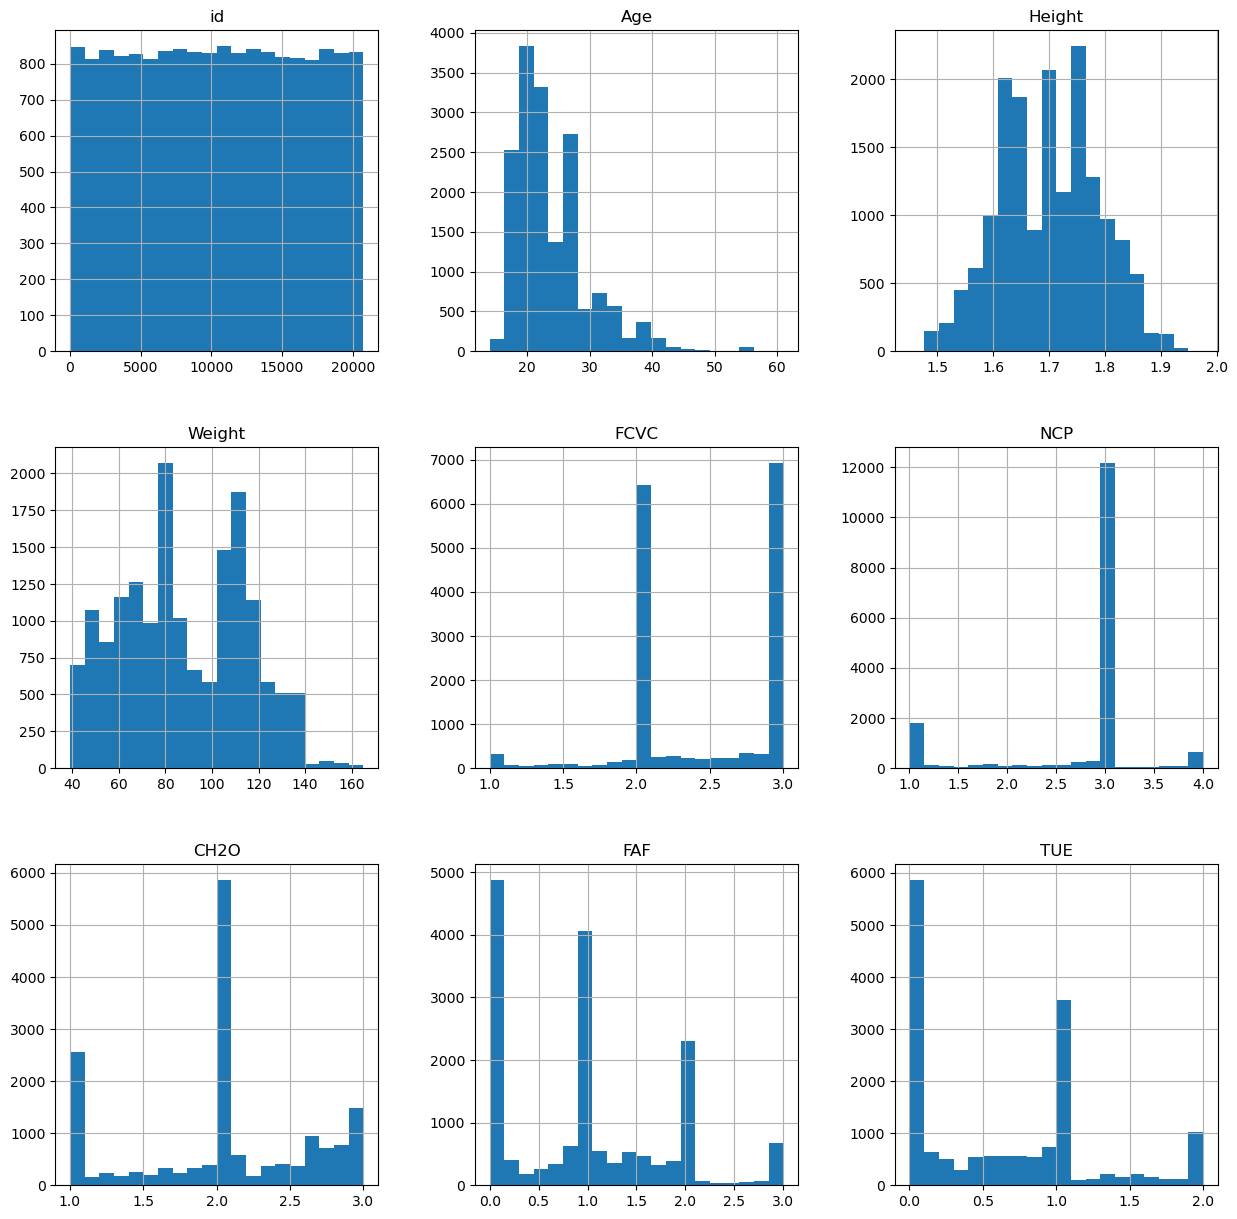

In [12]:
X_train.hist(bins=20,figsize=(15,15));

In [13]:
numric_columns = X_train.select_dtypes(include=[np.number]).columns

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


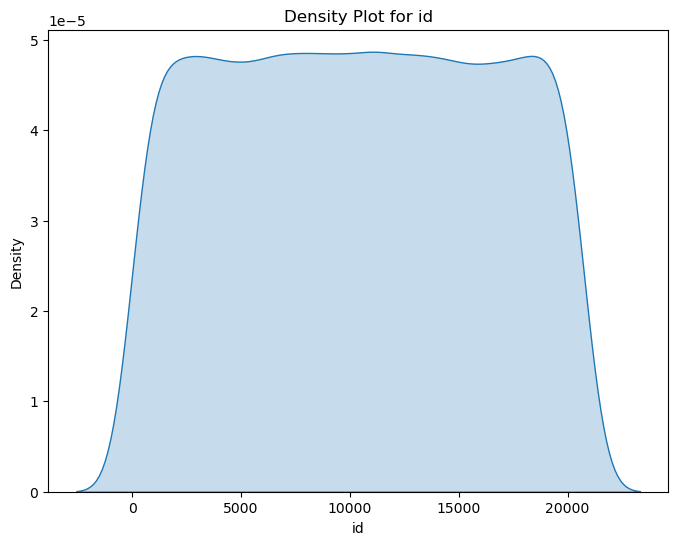

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


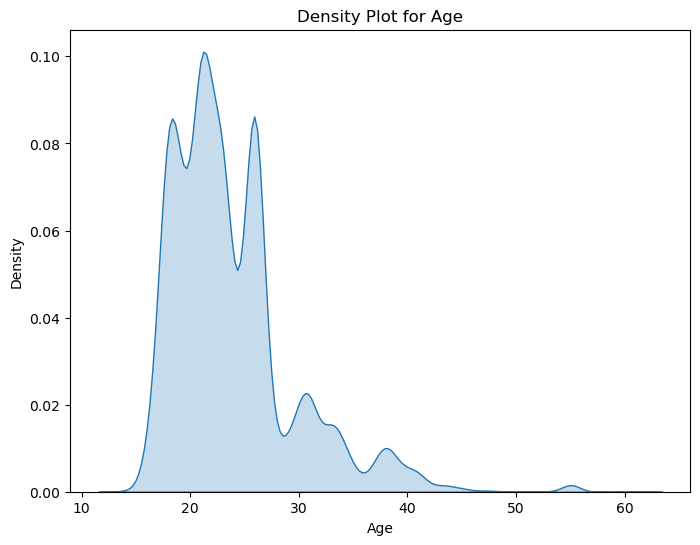

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


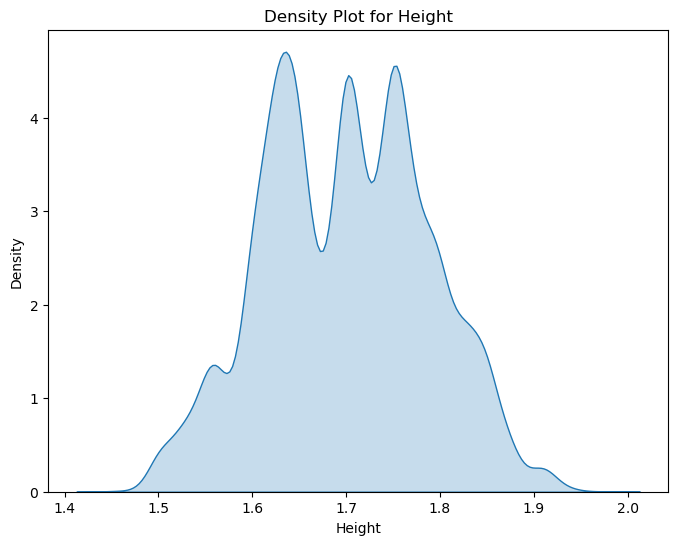

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


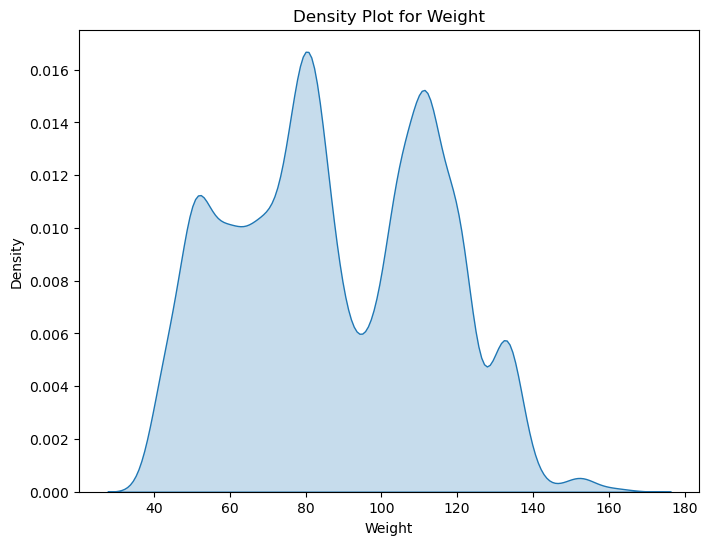

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


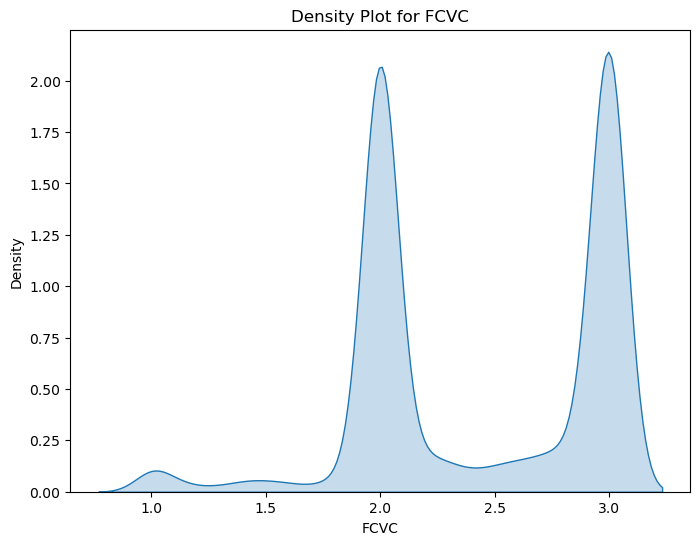

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


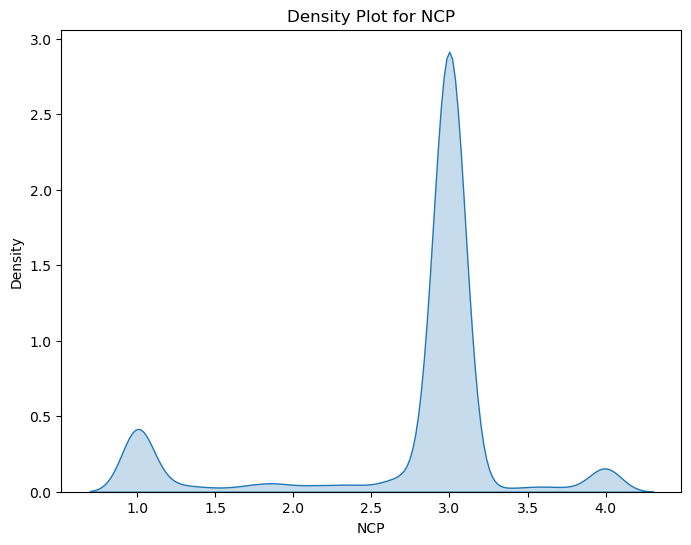

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


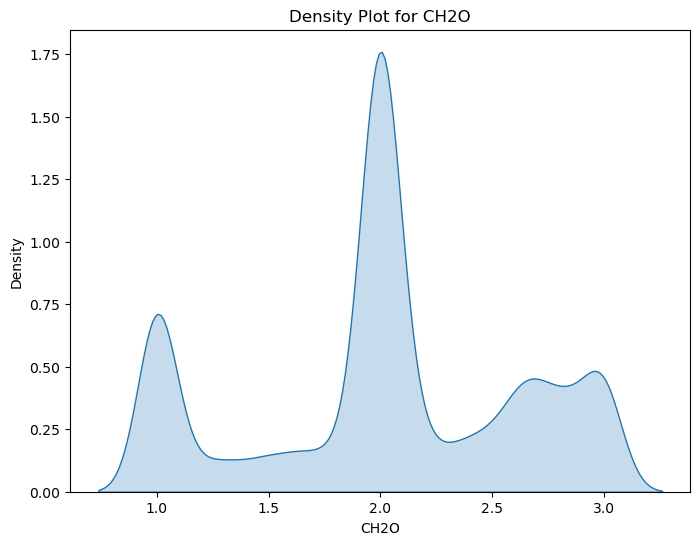

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


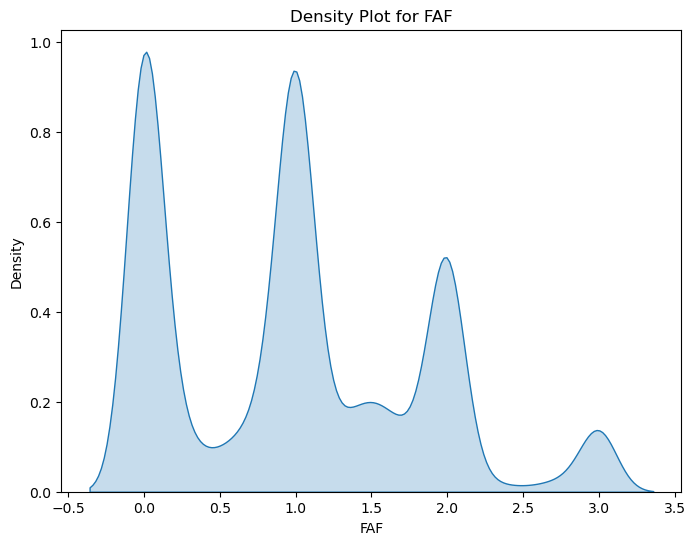

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_17152\750571215.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[column], shade=True)


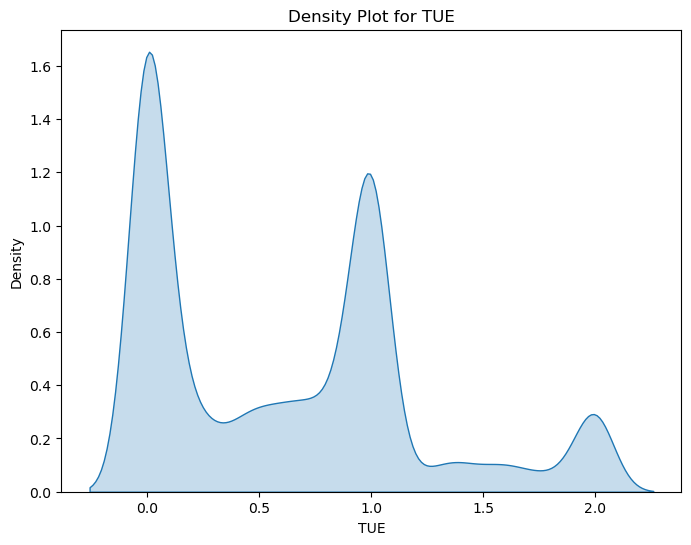

In [14]:
for column in numric_columns:
    plt.figure(figsize=(8, 6))
    sns.kdeplot(X_train[column], shade=True)
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.title(f'Density Plot for {column}')
    plt.show()

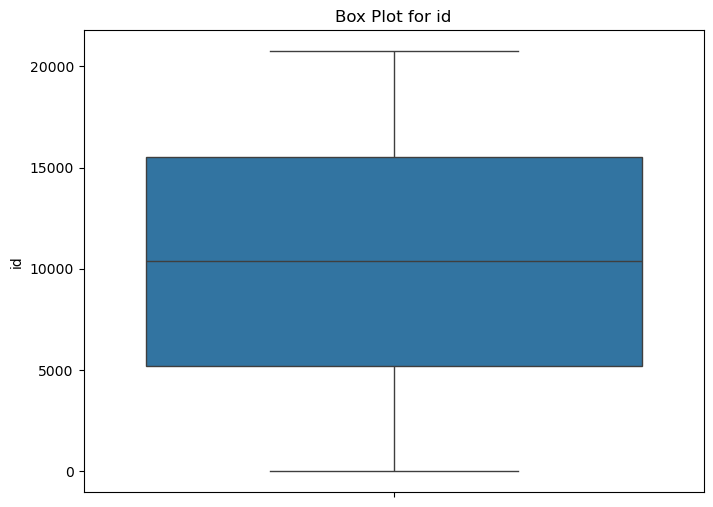

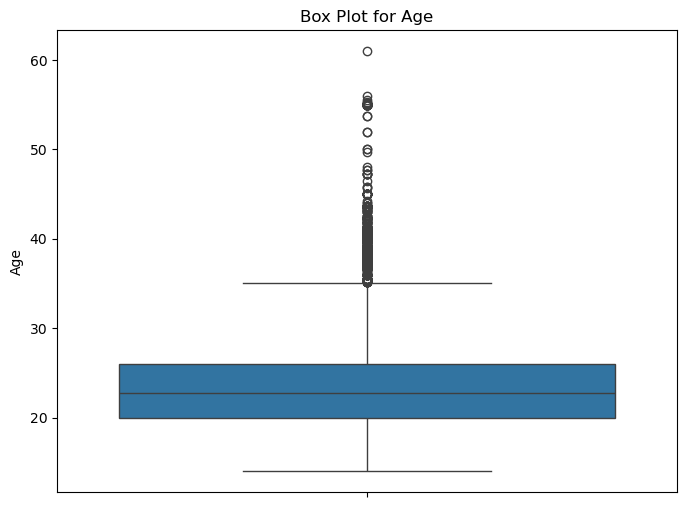

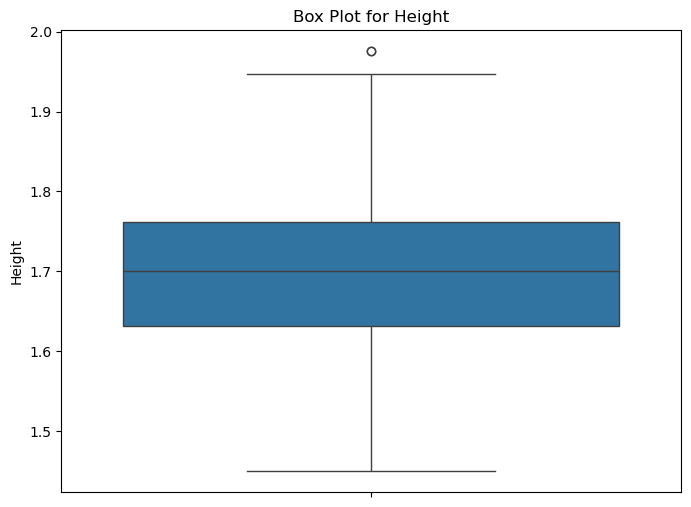

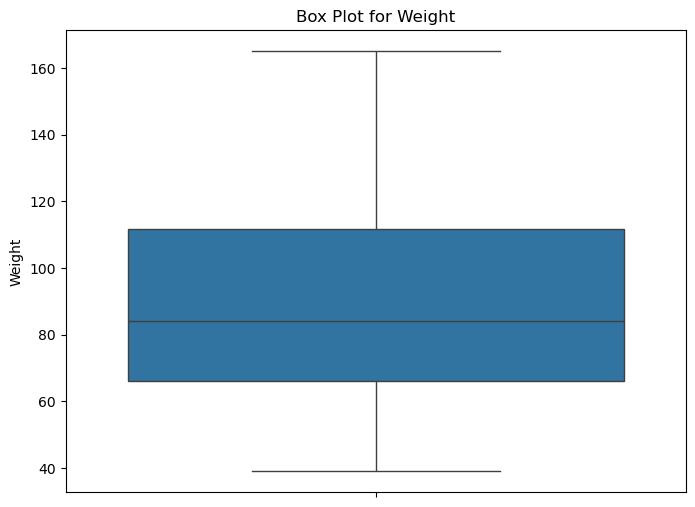

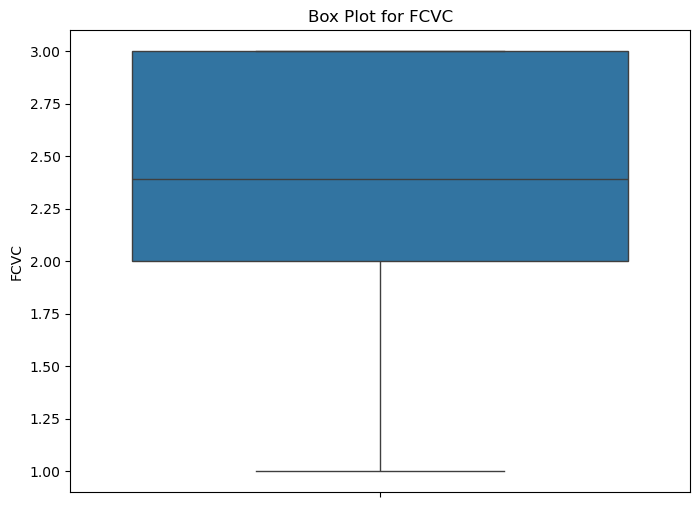

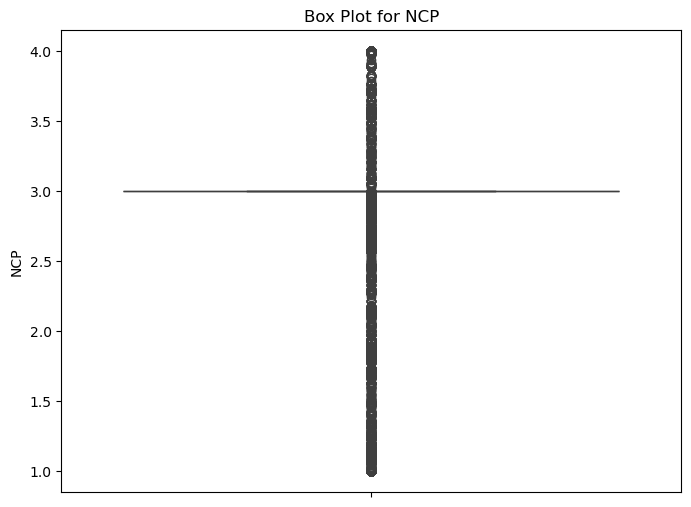

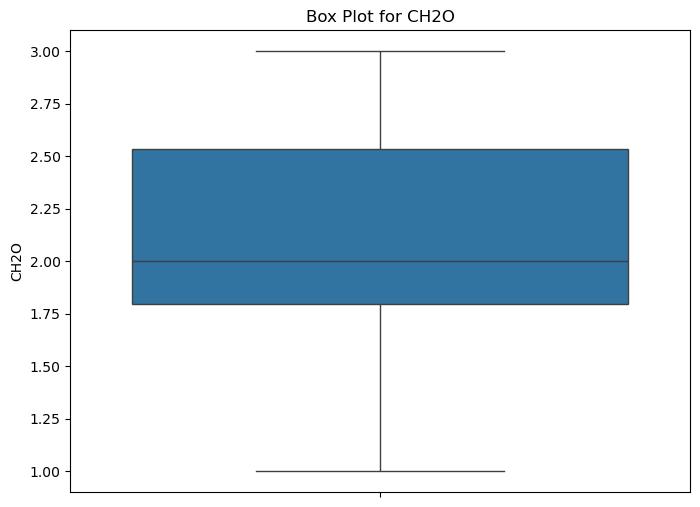

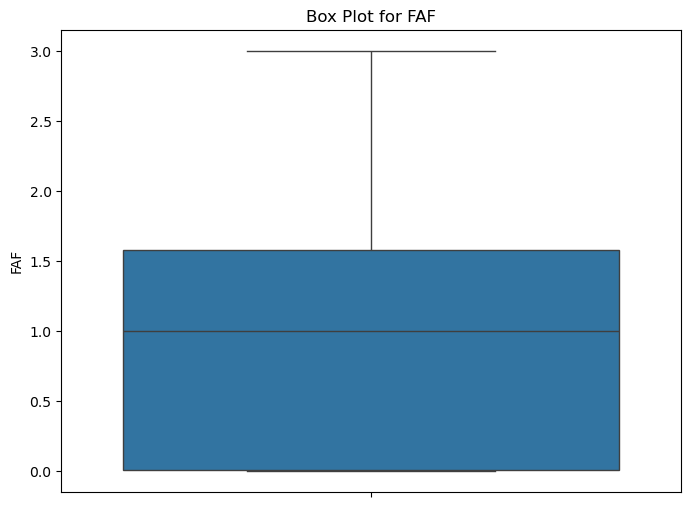

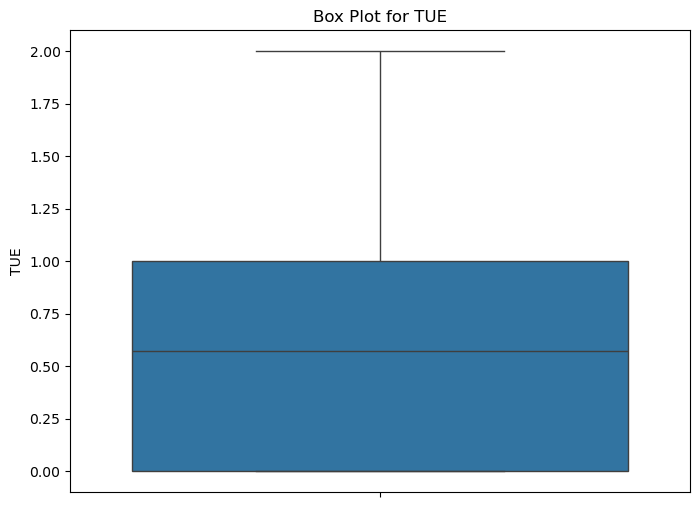

In [15]:
for column in numric_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=X_train[column])
    plt.ylabel(column)
    plt.title(f'Box Plot for {column}')
    plt.show()

#### bivariate visualization 

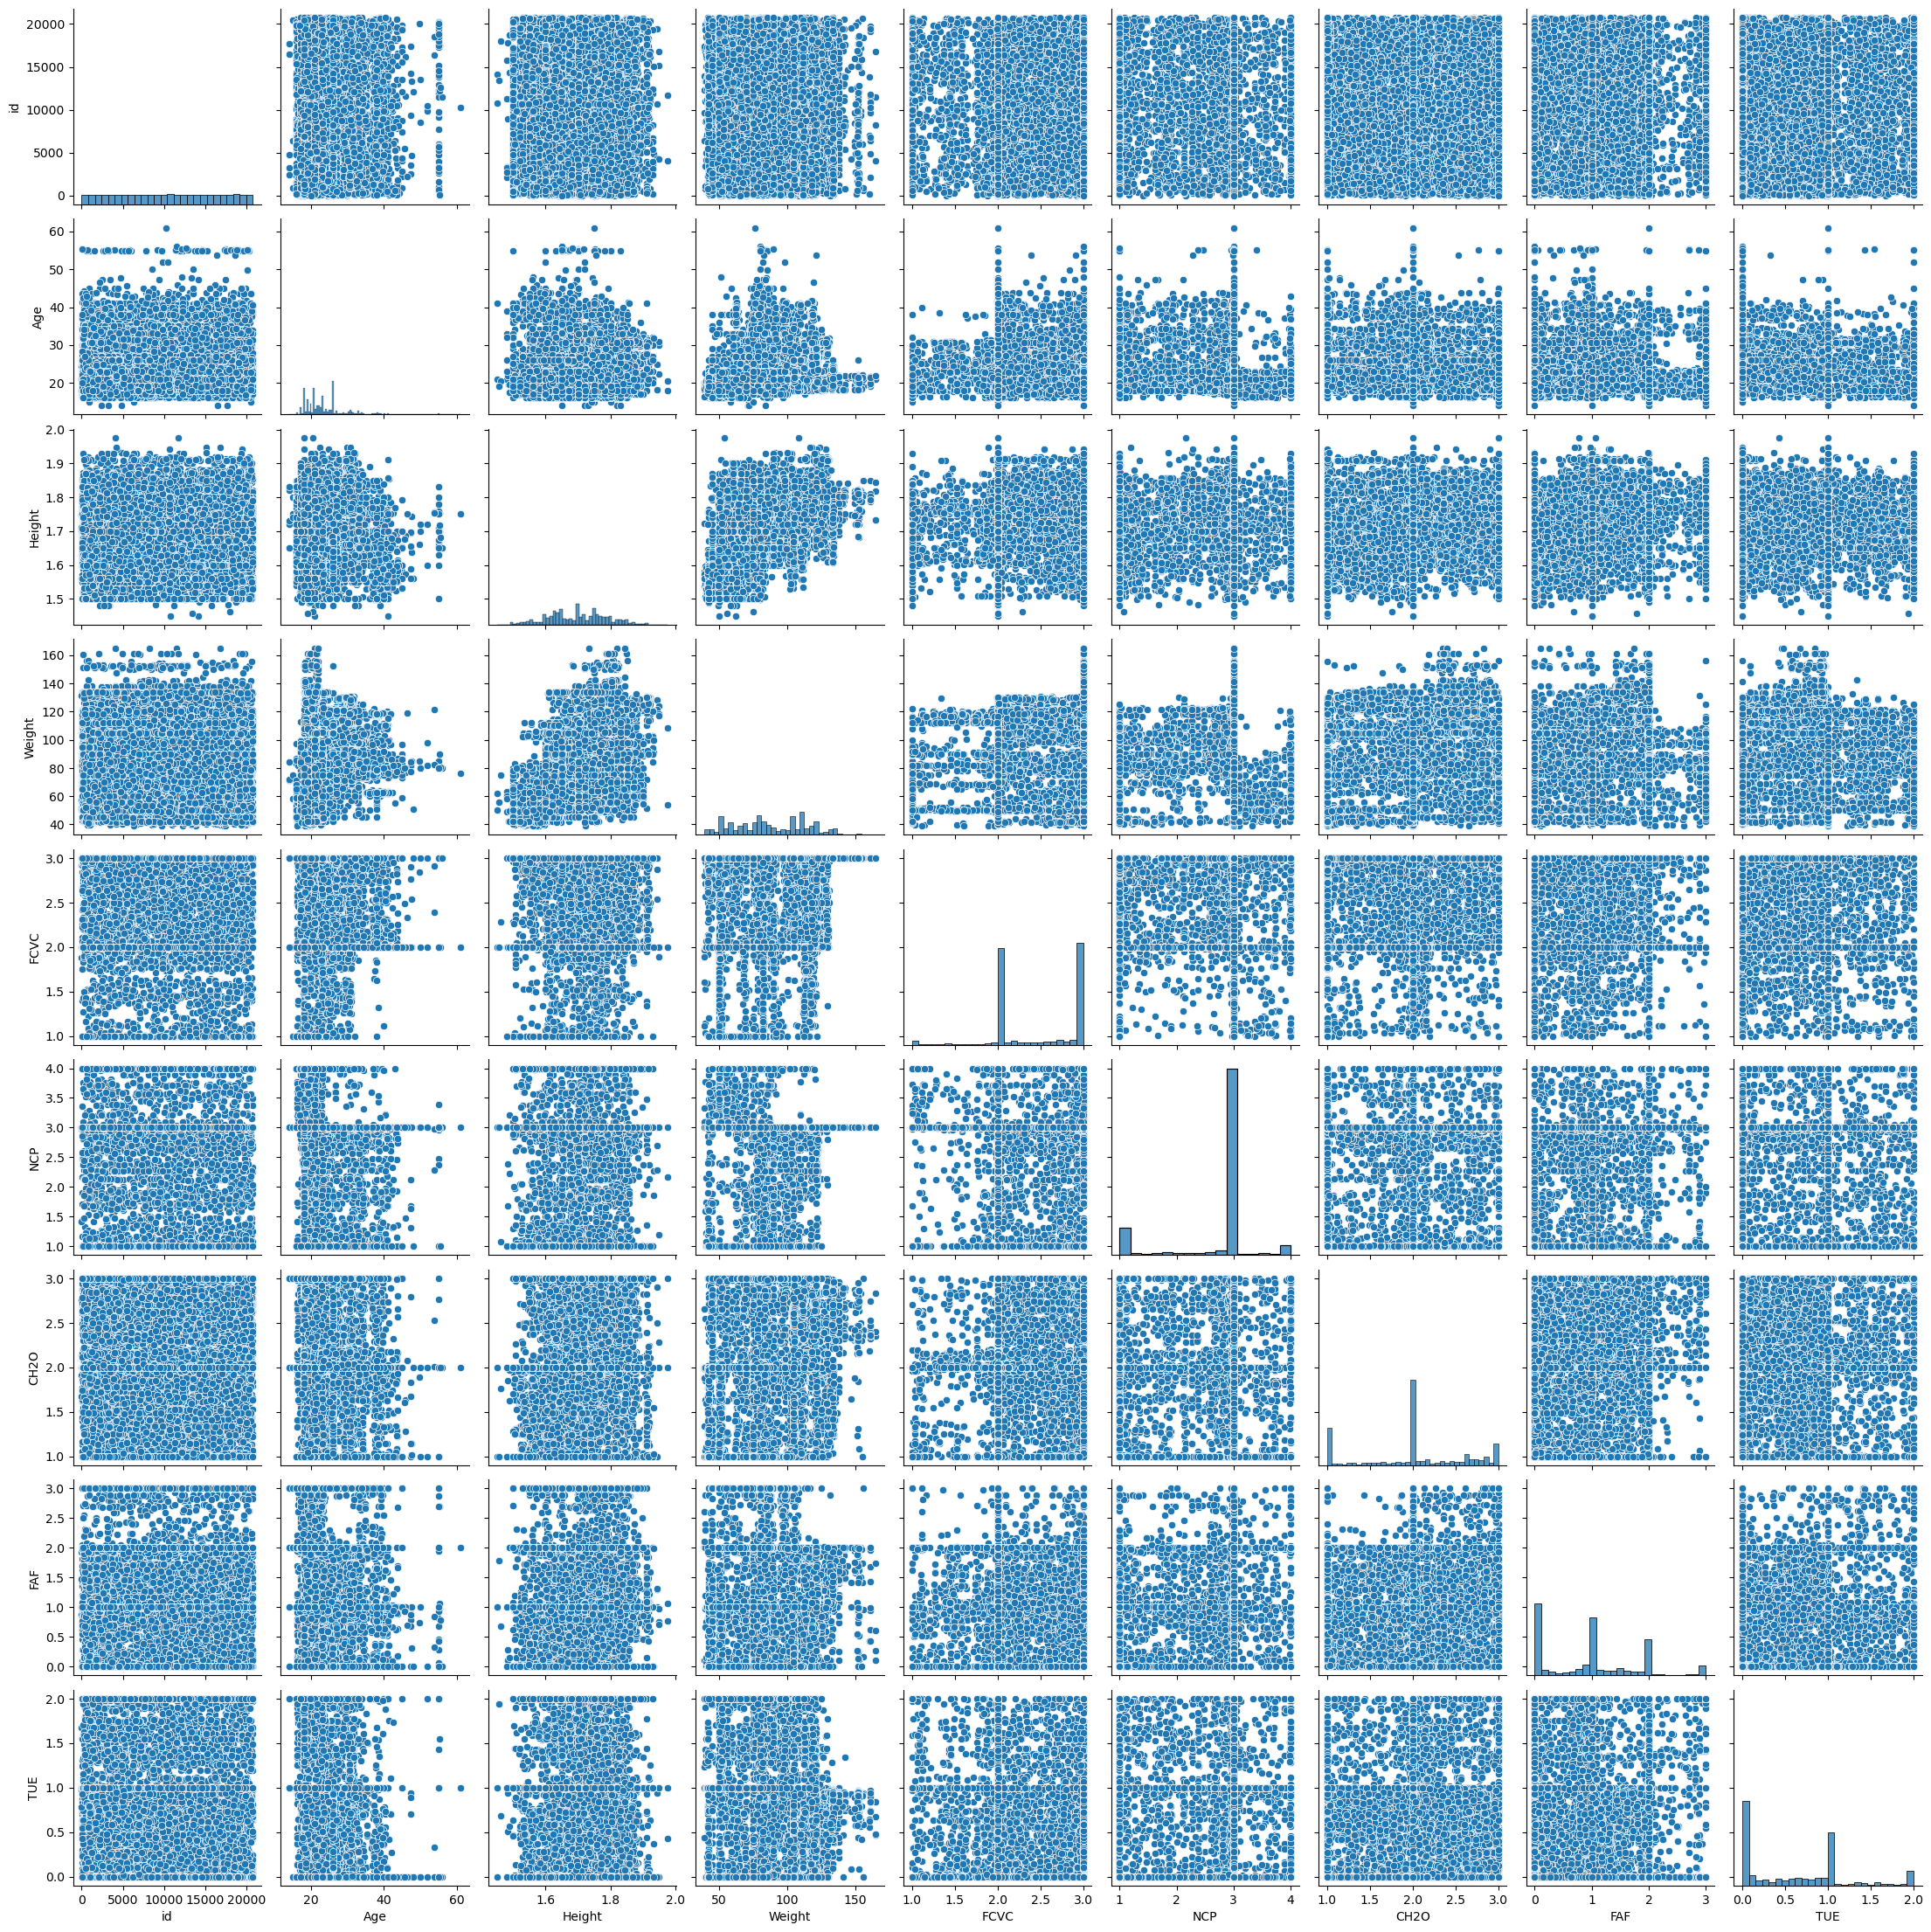

In [16]:
sns.pairplot(X_train)

#### multivarite visualization

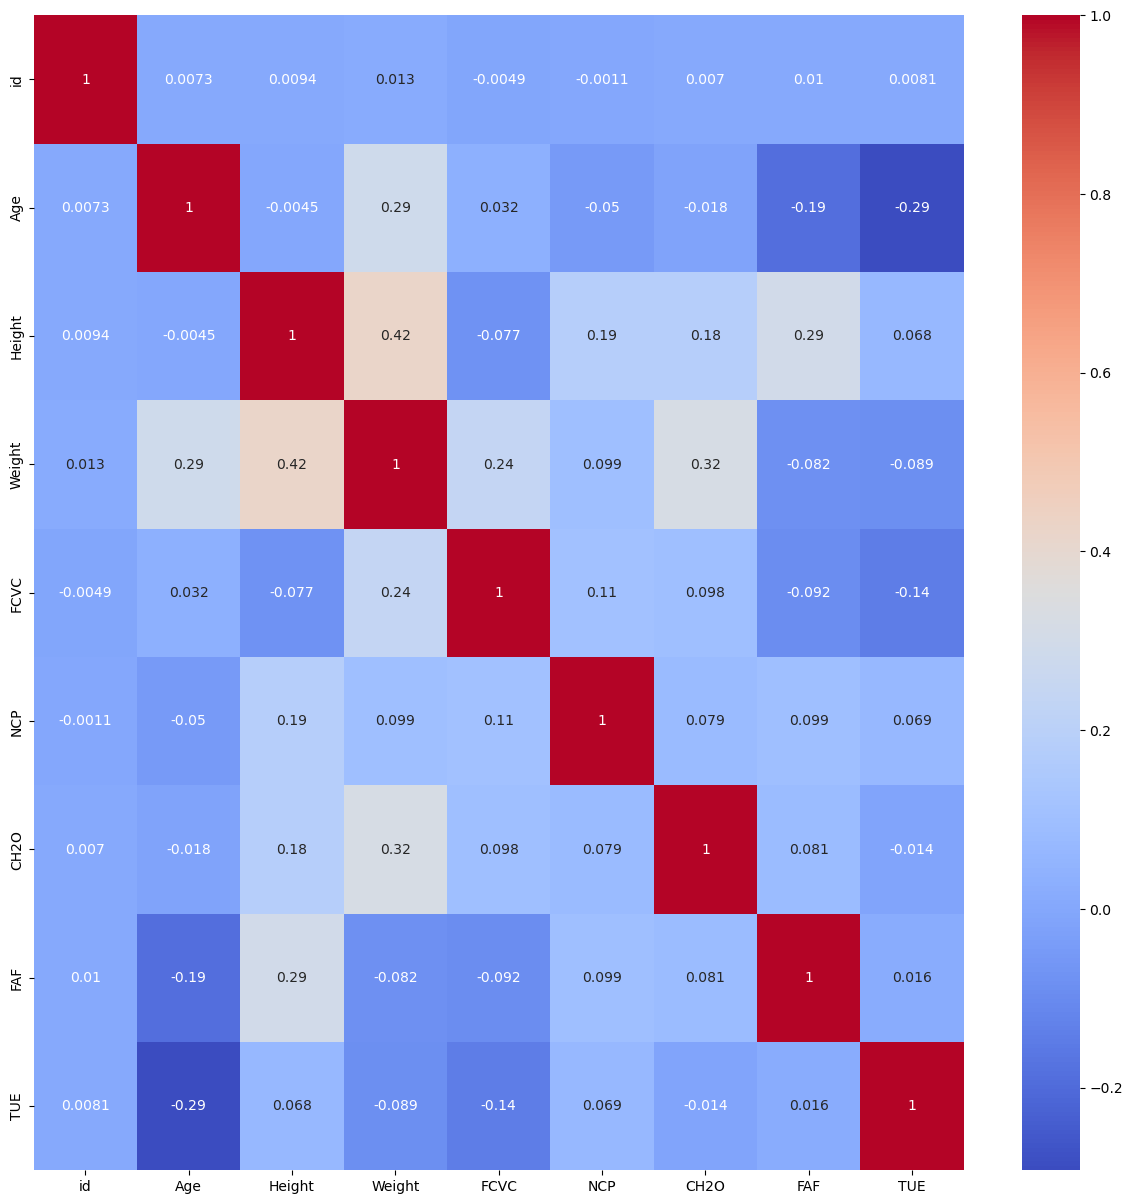

In [17]:
corr =  X_train.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True,cmap='coolwarm');

----------------

# `04` Data Preparation
Perform data cleaning, feature engineering, scaling, dropping unwanted columns (such as IDs), etc. as needed to make sure it's ready for the model.

In [ ]:
X_train = X_train.drop(["id","SMOKE","SCC"],axis=1)

In [19]:
X_train['NCP'] = X_train['NCP'].round()
X_train['FAF'] = X_train['FAF'].round()

In [ ]:
columns_to_encode = ['Gender', 'family_history_with_overweight', 'FAVC', 'MTRANS']

encoder = OneHotEncoder(drop="first", sparse_output=False)

x_train_onehot = encoder.fit_transform(X_train[columns_to_encode])
onehot_columns = encoder.get_feature_names_out(columns_to_encode)

onehot_df = pd.DataFrame(x_train_onehot, columns= onehot_columns, index=X_train.index)

X_train = X_train.drop(columns=columns_to_encode)

X_train = pd.concat([X_train, onehot_df], axis=1)


## `#` Prepare Test Set

Apply the data transformations you used on the training set to the test set.


In [26]:
X_val = X_val.drop(["id","SMOKE","SCC"],axis=1)
X_val['NCP'] = X_val['NCP'].round()
X_val['FAF'] = X_val['FAF'].round()

In [ ]:
columns_to_encode = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'CALC', 'MTRANS']

encoder = OneHotEncoder(drop="first", sparse_output=False)

x_val_onehot = encoder.fit_transform(X_val[columns_to_encode])
onehot_columns = encoder.get_feature_names_out(columns_to_encode)

onehot_df = pd.DataFrame(x_val_onehot, columns= onehot_columns, index=X_val.index)

X_val = X_val.drop(columns=columns_to_encode)

X_val = pd.concat([X_val, onehot_df], axis=1)


In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16606 entries, 13224 to 1318
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 16606 non-null  float64
 1   Height                              16606 non-null  float64
 2   Weight                              16606 non-null  float64
 3   FCVC                                16606 non-null  float64
 4   NCP                                 16606 non-null  float64
 5   CH2O                                16606 non-null  float64
 6   FAF                                 16606 non-null  float64
 7   TUE                                 16606 non-null  float64
 8   Gender_Male                         16606 non-null  float64
 9   family_history_with_overweight_yes  16606 non-null  float64
 10  FAVC_yes                            16606 non-null  float64
 11  CAEC_Frequently                     16606 n